# PV056 — Topic 1: Human Activity Recognition

Dataset: UCI HAR (smartphone inertial sensors)  
Goal: classify 6 activities; beat LSTM baseline (F1-macro > 0.80)

**General (every topic):**

- R1a — visualize class label distribution
- R1b — find/visualize outliers or anomalies
- R2a — use HPO (hyperparameter optimization) to find hyperparameters
- R2b — visualize training progress, train to convergence
- R3a — explore successful/failed cases (confusion matrix, explainability)
- R3b — present results in a suitable form

**Topic 1 specific:**
- T1a — data analysis to uncover tough cases (e.g. T-SNE, error analysis, sequence patterns like "does sitting→climbing stairs co-occur?")
- T1b — improve over the given LSTM baseline (~0.80 F1-macro)

## 1. Setup & Data Loading

In [47]:
# !pip install -r requirements.txt

In [48]:
%reset

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn
import sklearn as sk
import torch
import optuna


In [50]:
df_train = pd.read_csv("./data/train.csv")
df_test = pd.read_csv("./data/test.csv")

print(df_train.shape, df_test.shape)

(7352, 563) (2947, 563)


In [51]:
df_train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [52]:
df_test.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,-0.894088,...,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2,STANDING
1,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,-0.894088,...,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2,STANDING
2,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,-0.939260,...,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2,STANDING
3,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,-0.938610,...,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2,STANDING
4,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,-0.938610,...,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2,STANDING


## 2. [R1a] Class Label Distribution

In [53]:
df_train['Activity'].value_counts()

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

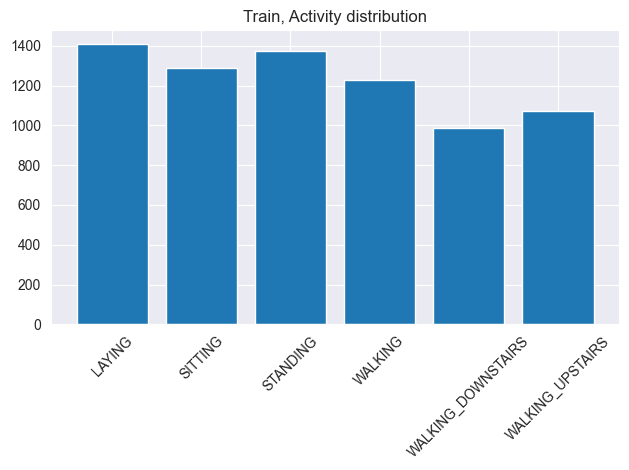

In [54]:
counts = df_train['Activity'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Train, Activity distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [55]:
df_test['Activity'].value_counts()

Activity
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64

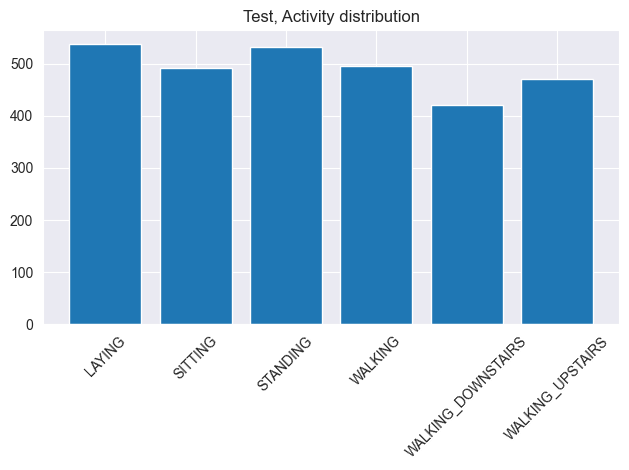

In [56]:
counts = df_test['Activity'].value_counts().sort_index()
plt.bar(counts.index, counts.values)
plt.title('Test, Activity distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [57]:
df_train['subject'].value_counts()

subject
25    409
21    408
26    392
30    383
28    382
27    376
23    372
17    368
16    366
19    360
1     347
29    344
3     341
15    328
6     325
14    323
22    321
11    316
7     308
5     302
8     281
Name: count, dtype: int64

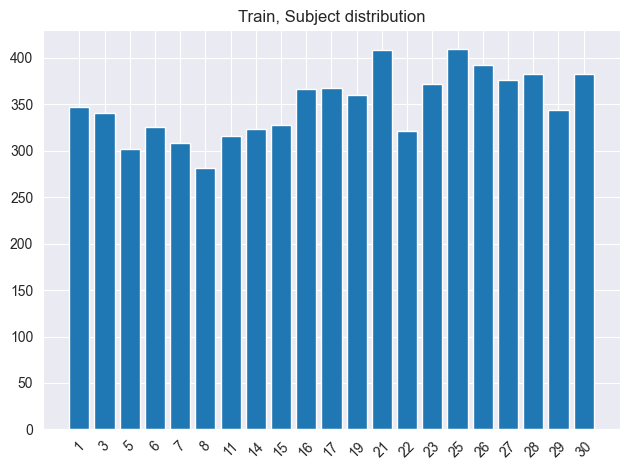

In [58]:
counts = df_train['subject'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Train, Subject distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Some subjects are missing in train.

Missing: 2, 4, 9, 10, 12, 13, 18, 20, 24

In [59]:
df_test['subject'].value_counts()

subject
24    381
18    364
20    354
13    327
12    320
4     317
2     302
10    294
9     288
Name: count, dtype: int64

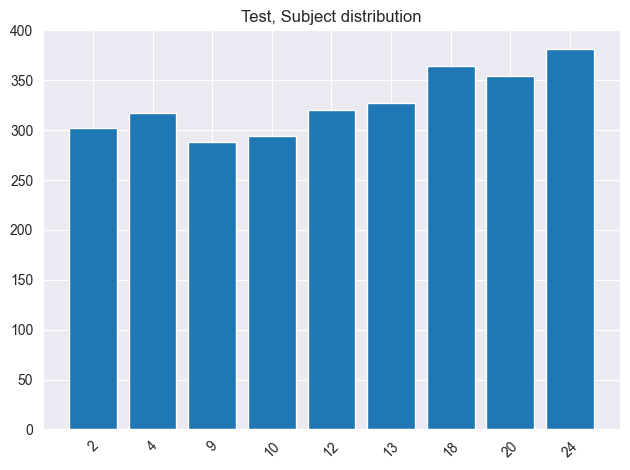

In [60]:
counts = df_test['subject'].value_counts().sort_index()
plt.bar(counts.index.astype(str), counts.values)
plt.title('Test, Subject distribution')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Missing subjects are found in test!

### **Notice that subjects in train and test are not the same!**

Test complements the train, be aware of that.

# Build baseline first

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

LABEL_COL = 'Activity'
DROP_COLS = ['Activity', 'subject']

X_train = df_train.drop(columns=DROP_COLS).values
y_train = df_train[LABEL_COL].values
X_test  = df_test.drop(columns=DROP_COLS).values
y_test  = df_test[LABEL_COL].values

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [62]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train)
print(f'LR   F1-macro: {f1_score(y_test, lr.predict(X_test_s), average="macro"):.4f}')

# Random Forest (tree-based, no scaling needed)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f'RF   F1-macro: {f1_score(y_test, rf.predict(X_test), average="macro"):.4f}')

print('Baseline target: 0.80')


LR   F1-macro: 0.9547
RF   F1-macro: 0.9234
Baseline target: 0.80


In [63]:
from sklearn.metrics import classification_report

print("=== Logistic Regression ===")
print(classification_report(y_test, lr.predict(X_test_s)))

print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))


=== Logistic Regression ===
                    precision    recall  f1-score   support

            LAYING       1.00      0.99      0.99       537
           SITTING       0.97      0.88      0.92       491
          STANDING       0.89      0.97      0.93       532
           WALKING       0.94      0.99      0.97       496
WALKING_DOWNSTAIRS       0.99      0.94      0.96       420
  WALKING_UPSTAIRS       0.96      0.95      0.95       471

          accuracy                           0.95      2947
         macro avg       0.96      0.95      0.95      2947
      weighted avg       0.96      0.95      0.95      2947

=== Random Forest ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.88      0.97      0.93       496
WALKING_DOWNSTAIRS       0.97      0.86      0

Results are quite surprising. Classical feature engineering + simple classifier outperforms a naive deep learning baseline. Im continuing with performing required steps and would try to improve the baseline

## 3. [R1b] Outlier / Anomaly Detection

Implementing PCA

In [66]:
from sklearn.decomposition import PCA

N_COMPONENTS = 50

pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_s)
X_train_reconstructed = pca.inverse_transform(X_train_pca)

reconstruction_errors = np.mean((X_train_s - X_train_reconstructed) ** 2, axis=1)


In [67]:
threshold = np.percentile(reconstruction_errors, 95)
outlier_mask = reconstruction_errors > threshold

print(f'Outliers detected: {outlier_mask.sum()} ({outlier_mask.mean()*100:.1f}%)')


Outliers detected: 368 (5.0%)


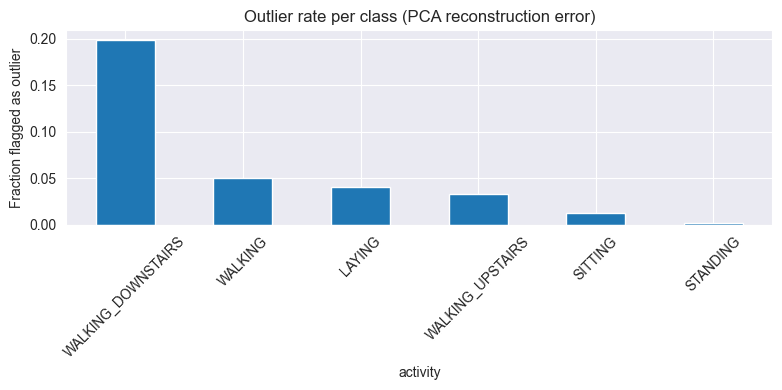

In [68]:
outlier_df = pd.DataFrame({
    'activity': y_train,
    'error': reconstruction_errors,
    'is_outlier': outlier_mask
})

outlier_rate = outlier_df.groupby('activity')['is_outlier'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
outlier_rate.plot(kind='bar')
plt.title('Outlier rate per class (PCA reconstruction error)')
plt.ylabel('Fraction flagged as outlier')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Results look logically. Standing data is quite the same in time, while walking downstairs makes hand move up and down intensively. We come back to it at the end.

## 4. [T1a] Tough Case Analysis

Be aware of differences between subject behaviours within the same class. Visualise per-subject variation within a class.

In [69]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_2d = tsne.fit_transform(X_train_s)

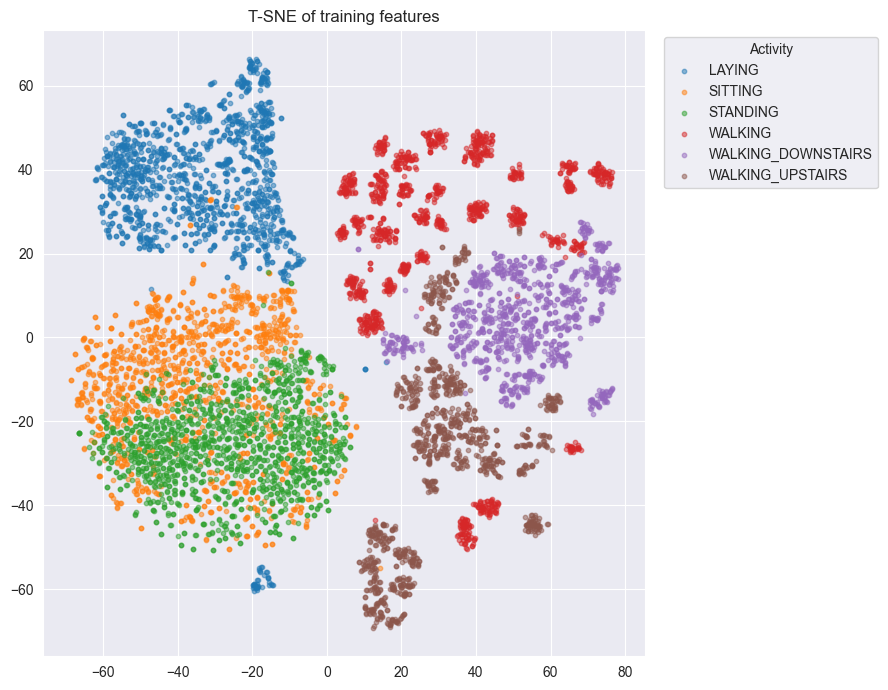

In [70]:
plt.figure(figsize=(9, 7))
for activity in np.unique(y_train):
    mask = y_train == activity
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=activity, alpha=0.5, s=10)
plt.legend(title='Activity', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title('T-SNE of training features')
plt.tight_layout()
plt.show()


walking  downstairs has a dense cluster, sitting and standing are quite mixxed up, sounds logically. Laying has its dense cluster as well. Walking has many small clusters, which may sign how people walk differently.

Interesting that T-SNE reveals two distinct regions: static activities (sitting, standing) form an overlapping cluster, while dynamic activities (waling variants) form separate but neighbouring sub-clusters. This explains the lower F1 scores for sitting and standing.

## 5. [R2a/R2b/T1b] Models, HPO, Training

When test different models, be aware of they might require different dataset preparation.
For example XGBoost (doesn't care about scaling (splits are based on rank/thresholds, not distances) vs Neural Networks (care a lot, unscaled features with very different ranges will make training unstable)

**Does the order of windows matter, and how do different models handle (or ignore) that sequence?**
That's the core difference between throwing XGBoost at it vs using an LSTM.

Let's try to implement and evaluate 4 models: XGBoost, SVM, LSTM and Transformer

### 1. XGBoost

In [71]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)


In [72]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'tree_method': 'hist',
        'eval_metric': 'mlogloss',
        'random_state': 42,
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train_enc)
    return f1_score(y_test_enc, model.predict(X_test), average='macro')

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print('Best F1-macro:', study_xgb.best_value)
print('Best params:', study_xgb.best_params)


[I 2026-04-14 19:07:57,959] A new study created in memory with name: no-name-97e824bf-596a-4230-914b-a3c98481a343
Best trial: 0. Best value: 0.940385:   3%|▎         | 1/30 [00:14<07:03, 14.60s/it]

[I 2026-04-14 19:08:12,557] Trial 0 finished with value: 0.9403852783047993 and parameters: {'n_estimators': 364, 'max_depth': 5, 'learning_rate': 0.03290506789251259, 'subsample': 0.7214304135950745, 'colsample_bytree': 0.7074390536148409}. Best is trial 0 with value: 0.9403852783047993.


Best trial: 0. Best value: 0.940385:   7%|▋         | 2/30 [00:38<09:23, 20.11s/it]

[I 2026-04-14 19:08:36,532] Trial 1 finished with value: 0.921438166256869 and parameters: {'n_estimators': 337, 'max_depth': 9, 'learning_rate': 0.0142340988615183, 'subsample': 0.7807172612175426, 'colsample_bytree': 0.7157396397514167}. Best is trial 0 with value: 0.9403852783047993.


Best trial: 0. Best value: 0.940385:  10%|█         | 3/30 [00:56<08:31, 18.93s/it]

...

[I 2026-04-14 19:13:00,673] Trial 27 finished with value: 0.9480919096905956 and parameters: {'n_estimators': 230, 'max_depth': 6, 'learning_rate': 0.17820466252376999, 'subsample': 0.680593210129022, 'colsample_bytree': 0.651709333333523}. Best is trial 13 with value: 0.9584602633197252.


Best trial: 13. Best value: 0.95846:  97%|█████████▋| 29/30 [05:11<00:08,  8.21s/it]

[I 2026-04-14 19:13:09,069] Trial 28 finished with value: 0.9494269631149027 and parameters: {'n_estimators': 290, 'max_depth': 5, 'learning_rate': 0.13671445259020007, 'subsample': 0.8470372905127544, 'colsample_bytree': 0.686922902325112}. Best is trial 13 with value: 0.9584602633197252.


Best trial: 13. Best value: 0.95846: 100%|██████████| 30/30 [05:18<00:00, 10.62s/it]

[I 2026-04-14 19:13:16,674] Trial 29 finished with value: 0.925611119429755 and parameters: {'n_estimators': 183, 'max_depth': 4, 'learning_rate': 0.02647829827612846, 'subsample': 0.742850836442553, 'colsample_bytree': 0.7032858828600348}. Best is trial 13 with value: 0.9584602633197252.
Best F1-macro: 0.9584602633197252
Best params: {'n_estimators': 417, 'max_depth': 3, 'learning_rate': 0.1215005252852689, 'subsample': 0.6676844263006803, 'colsample_bytree': 0.6708623618220193}


### 2. SVM

In [73]:
from sklearn.svm import SVC

def svm_objective(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 100, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'linear']),
        'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
    }
    model = SVC(**params)
    model.fit(X_train_s, y_train)
    return f1_score(y_test, model.predict(X_test_s), average='macro')

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(svm_objective, n_trials=20, show_progress_bar=True)
print('SVM Best F1-macro:', study_svm.best_value)
print('SVM Best params:', study_svm.best_params)


[I 2026-04-14 19:13:16,766] A new study created in memory with name: no-name-f6fe2248-b987-4869-9e66-60b73aa43307
Best trial: 0. Best value: 0.946982:   5%|▌         | 1/20 [00:02<00:52,  2.77s/it]

[I 2026-04-14 19:13:19,533] Trial 0 finished with value: 0.9469817003466575 and parameters: {'C': 0.5776697952162028, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.9469817003466575.


Best trial: 0. Best value: 0.946982:  10%|█         | 2/20 [00:06<01:02,  3.46s/it]

[I 2026-04-14 19:13:23,484] Trial 1 finished with value: 0.9353841218881879 and parameters: {'C': 0.14977070330248593, 'kernel': 'rbf', 'gamma': 'scale'}. Best is trial 0 with value: 0.9469817003466575.


Best trial: 2. Best value: 0.955237:  15%|█▌        | 3/20 [00:08<00:47,  2.79s/it]

...

[I 2026-04-14 19:13:37,725] Trial 17 finished with value: 0.9605058221726611 and parameters: {'C': 0.872835920354807, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 9 with value: 0.9615390629491635.


Best trial: 9. Best value: 0.961539:  95%|█████████▌| 19/20 [00:25<00:01,  1.87s/it]

[I 2026-04-14 19:13:42,287] Trial 18 finished with value: 0.9251230086215106 and parameters: {'C': 0.10350607363977378, 'kernel': 'rbf', 'gamma': 'auto'}. Best is trial 9 with value: 0.9615390629491635.


Best trial: 9. Best value: 0.961539: 100%|██████████| 20/20 [00:26<00:00,  1.31s/it]

[I 2026-04-14 19:13:42,964] Trial 19 finished with value: 0.9605360725695768 and parameters: {'C': 0.29687385631791996, 'kernel': 'linear', 'gamma': 'auto'}. Best is trial 9 with value: 0.9615390629491635.
SVM Best F1-macro: 0.9615390629491635
SVM Best params: {'C': 0.1306075644754394, 'kernel': 'linear', 'gamma': 'auto'}


### 3. LSTM

In [74]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_train_t = torch.tensor(y_train_enc, dtype=torch.long)
y_test_t  = torch.tensor(y_test_enc,  dtype=torch.long)

class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout, n_classes):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(hidden_size, n_classes))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :])

def train_and_eval(model, X_tr, y_tr, X_te, y_te, lr, epochs, batch_size):
    dl = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)
    for _ in range(epochs):
        model.train()
        for Xb, yb in dl:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            criterion(model(Xb), yb).backward()
            opt.step()
    model.eval()
    with torch.no_grad():
        preds = model(X_te.to(DEVICE)).argmax(1).cpu().numpy()
    return f1_score(y_te.numpy(), preds, average='macro')

def lstm_objective(trial):
    hidden = trial.suggest_categorical('hidden_size', [64, 128, 256])
    layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.1, 0.5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    bs = trial.suggest_categorical('batch_size', [64, 128])
    model = LSTMClassifier(X_train_s.shape[1], hidden, layers, dropout, len(le.classes_))
    # reshape to (samples, 1, features) — single timestep
    return train_and_eval(model,
                          X_train_t.unsqueeze(1), y_train_t,
                          X_test_t.unsqueeze(1),  y_test_t,
                          lr=lr, epochs=20, batch_size=bs)

study_lstm = optuna.create_study(direction='maximize')
study_lstm.optimize(lstm_objective, n_trials=20, show_progress_bar=True)
print('LSTM Best F1-macro:', study_lstm.best_value)
print('LSTM Best params:', study_lstm.best_params)


[I 2026-04-14 19:13:43,030] A new study created in memory with name: no-name-52e318a1-c2fd-4e1b-b510-cb83c9924f4c


Device: mps


Best trial: 0. Best value: 0.941692:   5%|▌         | 1/20 [00:03<01:14,  3.94s/it]

[I 2026-04-14 19:13:46,974] Trial 0 finished with value: 0.9416922784974421 and parameters: {'hidden_size': 64, 'num_layers': 3, 'dropout': 0.31055314689414815, 'lr': 0.000141163939418028, 'batch_size': 128}. Best is trial 0 with value: 0.9416922784974421.


Best trial: 1. Best value: 0.947372:  10%|█         | 2/20 [00:09<01:30,  5.03s/it]

...

[I 2026-04-14 19:15:10,922] Trial 17 finished with value: 0.9423222114886777 and parameters: {'hidden_size': 256, 'num_layers': 2, 'dropout': 0.2755460536881146, 'lr': 0.0007623286656622233, 'batch_size': 64}. Best is trial 9 with value: 0.9496146254310697.


Best trial: 9. Best value: 0.949615:  95%|█████████▌| 19/20 [01:33<00:06,  6.03s/it]

[I 2026-04-14 19:15:16,865] Trial 18 finished with value: 0.9372977925676341 and parameters: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.34290031502164375, 'lr': 0.009867370106512105, 'batch_size': 64}. Best is trial 9 with value: 0.9496146254310697.


Best trial: 9. Best value: 0.949615: 100%|██████████| 20/20 [01:39<00:00,  4.98s/it]

[I 2026-04-14 19:15:22,566] Trial 19 finished with value: 0.9430365328314605 and parameters: {'hidden_size': 256, 'num_layers': 1, 'dropout': 0.1845512457097051, 'lr': 0.003815102891788181, 'batch_size': 64}. Best is trial 9 with value: 0.9496146254310697.
LSTM Best F1-macro: 0.9496146254310697
LSTM Best params: {'hidden_size': 128, 'num_layers': 2, 'dropout': 0.2294439205796227, 'lr': 0.0007308743959638758, 'batch_size': 64}


Looks like the feature engineering is the bottleneck, not the model complexity. Every model F1-score is around 0.95-0.96. Interesting that LSTM underperforms classical models probably because the pre-extracted features lack temporal structure, each sample is a single window, not a sequence.

### Show training curve on LSTM

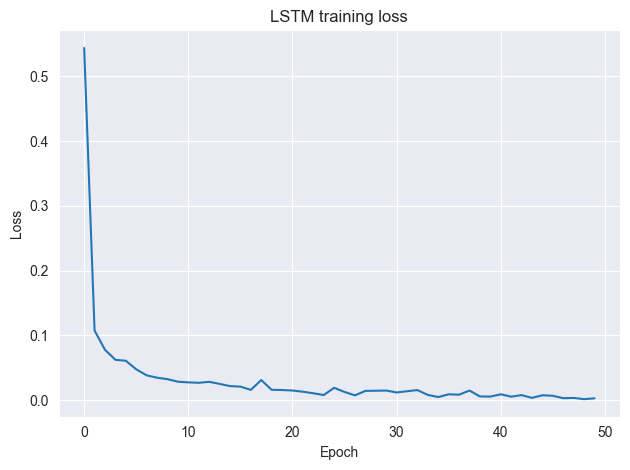

In [75]:
best_lstm_params = study_lstm.best_params

model = LSTMClassifier(
    input_size=X_train_s.shape[1],
    hidden_size=best_lstm_params['hidden_size'],
    num_layers=best_lstm_params['num_layers'],
    dropout=best_lstm_params['dropout'],
    n_classes=len(le.classes_)
).to(DEVICE)

dl = DataLoader(
    TensorDataset(X_train_t.unsqueeze(1), y_train_t),
    batch_size=best_lstm_params['batch_size'],
    shuffle=True
)

opt = torch.optim.Adam(model.parameters(), lr=best_lstm_params['lr'])
criterion = nn.CrossEntropyLoss()

train_losses = []

for epoch in range(50):
    model.train()
    epoch_loss = 0
    for Xb, yb in dl:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad()
        loss = criterion(model(Xb), yb)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(dl))

plt.plot(train_losses)
plt.title('LSTM training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()


## 6. [R3a/R3b] Results & Analysis

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(colorbar=False, cmap='Blues', xticks_rotation=30)
    plt.title(title)
    plt.tight_layout()
    plt.show()



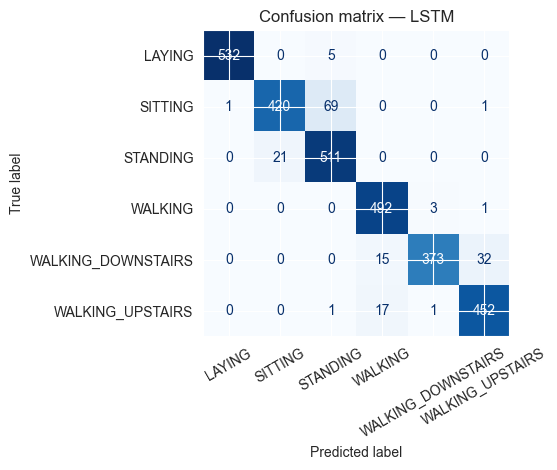

In [77]:
model.eval()
with torch.no_grad():
    lstm_preds = le.inverse_transform(model(X_test_t.unsqueeze(1).to(DEVICE)).argmax(1).cpu().numpy())

plot_cm(y_test, lstm_preds, 'Confusion matrix — LSTM')


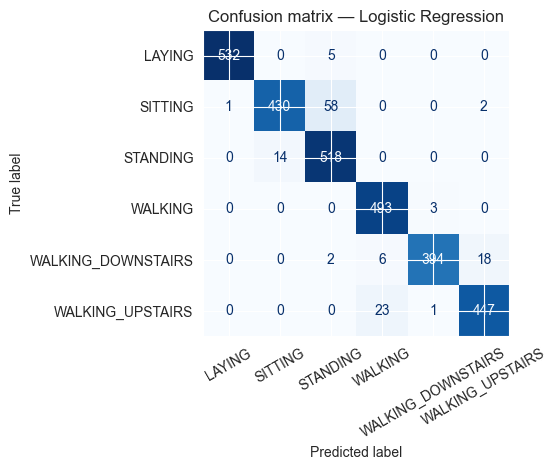

In [78]:
plot_cm(y_test, lr.predict(X_test_s), 'Confusion matrix — Logistic Regression')


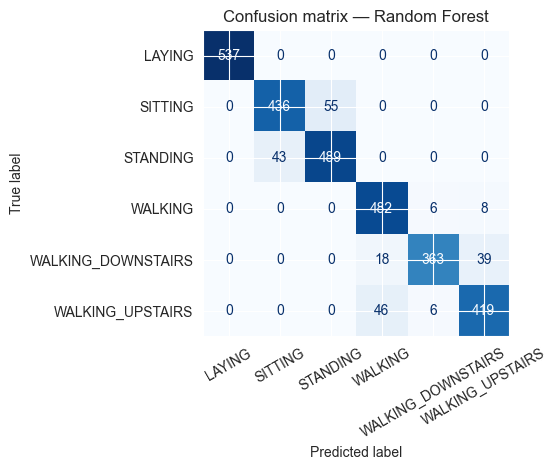

In [79]:
plot_cm(y_test, rf.predict(X_test), 'Confusion matrix — Random Forest')


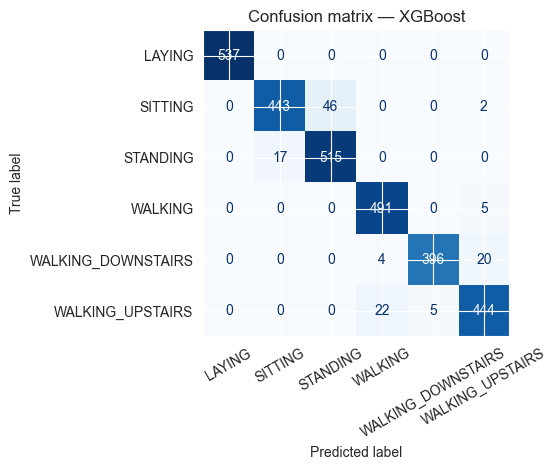

In [80]:
best_xgb = xgb.XGBClassifier(**study_xgb.best_params, tree_method='hist', device='cpu', random_state=42)
best_xgb.fit(X_train, y_train_enc)

plot_cm(y_test, le.inverse_transform(best_xgb.predict(X_test)), 'Confusion matrix — XGBoost')


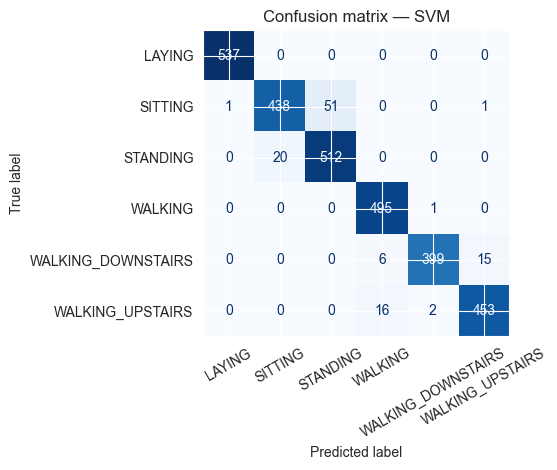

In [82]:
best_svm = SVC(kernel='linear', C=study_svm.best_params['C'], gamma='auto')
best_svm.fit(X_train_s, y_train)
y_pred_svm = best_svm.predict(X_test_s)

plot_cm(y_test, y_pred_svm, 'Confusion matrix — SVM')


## Results table

In [85]:
results = pd.DataFrame([
    {'Model': 'Random Forest', 'F1-macro': f1_score(y_test, rf.predict(X_test), average='macro')},
    {'Model': 'LSTM (HPO)', 'F1-macro': f1_score(y_test, lstm_preds, average='macro')},
    {'Model': 'Logistic Regression', 'F1-macro': f1_score(y_test, lr.predict(X_test_s), average='macro')},
    {'Model': 'XGBoost (HPO)', 'F1-macro': f1_score(y_test, le.inverse_transform(best_xgb.predict(X_test)), average='macro')},
    {'Model': 'SVM (HPO)', 'F1-macro': f1_score(y_test, y_pred_svm, average='macro')},
]).sort_values('F1-macro')

print(results.to_string(index=False))


              Model  F1-macro
      Random Forest  0.923431
         LSTM (HPO)  0.942524
Logistic Regression  0.954718
      XGBoost (HPO)  0.958460
          SVM (HPO)  0.961539


## Feature importance (XGBoost)

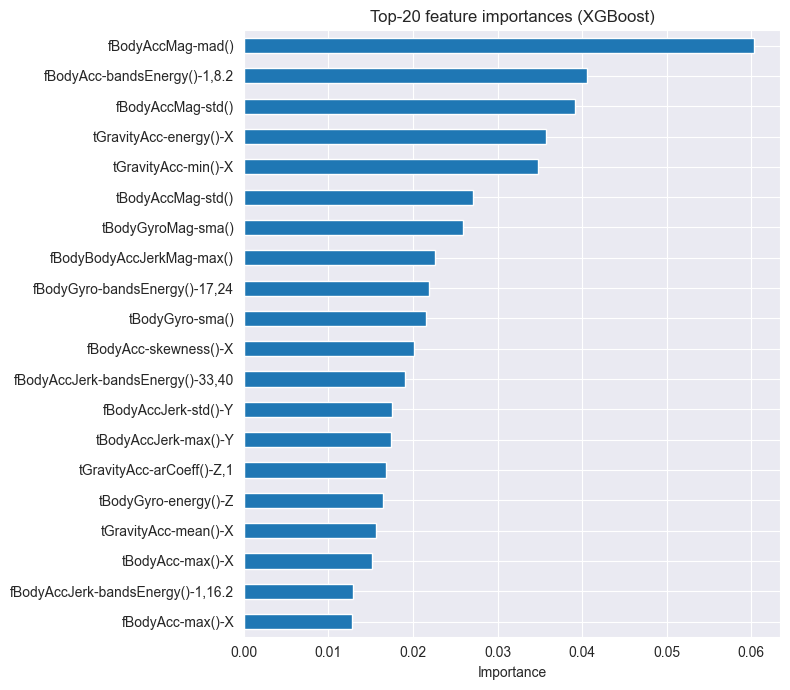

In [86]:
importances = pd.Series(best_xgb.feature_importances_,
                        index=df_train.drop(columns=['Activity', 'subject']).columns)
top20 = importances.nlargest(20).sort_values()

top20.plot(kind='barh', figsize=(8, 7), title='Top-20 feature importances (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
